# Moomoo and Friends' Code!

## Let's import the data!

In [92]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt 
sb.set() # set the default Seaborn style for graphics
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import numpy as np
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [93]:
#Similarly, you'll need to change the file location to match your own for this to work
data = pd.read_csv('C:/Users/zitin/Documents/BAC Datathon/Theme 1.csv')
data.head()

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7,NaN,Tablet,Credit Card,3/1/2024,True,False,Need-based,No Preference,2
1,29-392-9296,49,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5,High,Tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6
2,84-649-5117,24,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,3
3,48-980-6078,29,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,$101.31,...,1,NaN,Smartphone,Other,10/4/2024,True,True,Need-based,Express,10
4,91-170-9072,33,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,10,NaN,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4


In [94]:
print("Data type : ", type(data))
print("Data dims : ", data.shape)
print(data.dtypes)

Data type :  <class 'pandas.core.frame.DataFrame'>
Data dims :  (1000, 28)
Customer_ID                               object
Age                                        int64
Gender                                    object
Income_Level                              object
Marital_Status                            object
Education_Level                           object
Occupation                                object
Location                                  object
Purchase_Category                         object
Purchase_Amount                           object
Frequency_of_Purchase                      int64
Purchase_Channel                          object
Brand_Loyalty                              int64
Product_Rating                             int64
Time_Spent_on_Product_Research(hours)    float64
Social_Media_Influence                    object
Discount_Sensitivity                      object
Return_Rate                                int64
Customer_Satisfaction                      

### We need to clean Purchase_Amount, so it can be treated as a continuous variable, a float

In [95]:
data["Purchase_Amount"] = (
    data["Purchase_Amount"]
    .replace('[\$,]', '', regex=True)  # removes $ and ,
    .astype(float)
)

# Let's try using a Classification Tree model to predict Purchase Intent

Categorical variables: ['Gender', 'Income_Level', 'Marital_Status', 'Education_Level', 'Occupation', 'Location', 'Purchase_Category', 'Purchase_Channel', 'Social_Media_Influence', 'Discount_Sensitivity', 'Engagement_with_Ads', 'Device_Used_for_Shopping', 'Payment_Method', 'Shipping_Preference']
Numeric variables: ['Age', 'Purchase_Amount', 'Frequency_of_Purchase', 'Brand_Loyalty', 'Product_Rating', 'Time_Spent_on_Product_Research(hours)', 'Customer_Satisfaction', 'Time_to_Decision']
Goodness of Fit of Model 	Train Dataset
Classification Accuracy 	: 0.976

Goodness of Fit of Model 	Test Dataset
Classification Accuracy 	: 0.256



<Axes: >

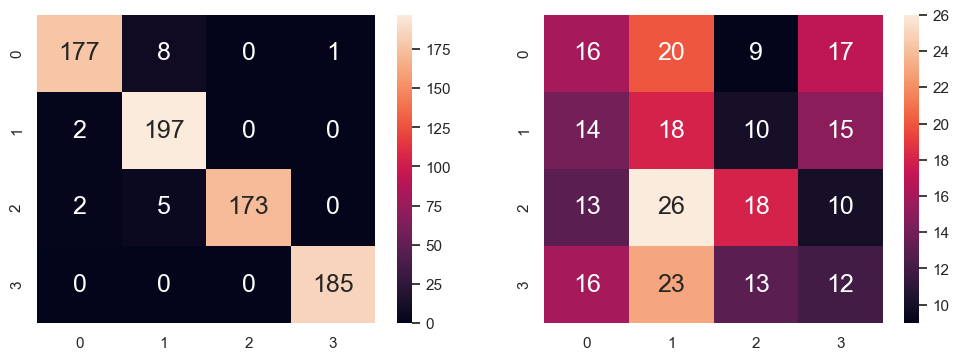

In [96]:
# Extract Response and Predictors
y = pd.DataFrame(data['Purchase_Intent']) #Response
X = data.drop(["Purchase_Intent","Customer_ID","Return_Rate","Time_of_Purchase"], axis=1) #Predictors

#Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object", "category"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical variables:", categorical_cols.tolist())
print("Numeric variables:", numeric_cols.tolist())

#Convert categorical variables into numbers
encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
X_encoded = pd.DataFrame(
    encoder.fit_transform(X[categorical_cols]),
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X.index
)

#Combine 
X_final = pd.concat([X[numeric_cols].reset_index(drop=True), X_encoded.reset_index(drop=True)], axis=1)

# Split the Dataset into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size = 0.25)

# Decision Tree using Train Data
dectree = DecisionTreeClassifier(max_depth = 15)  # create the decision tree object
dectree.fit(X_train, y_train)                    # train the decision tree model

# Predict Response corresponding to Predictors
y_train_pred = dectree.predict(X_train)
y_test_pred = dectree.predict(X_test)

# Check the Goodness of Fit (on Train Data)
print("Goodness of Fit of Model \tTrain Dataset")
print("Classification Accuracy \t:", dectree.score(X_train, y_train))
print()

# Check the Goodness of Fit (on Test Data)
print("Goodness of Fit of Model \tTest Dataset")
print("Classification Accuracy \t:", dectree.score(X_test, y_test))
print()

# Plot the Confusion Matrix for Train and Test
f, axes = plt.subplots(1, 2, figsize=(12, 4))
sb.heatmap(confusion_matrix(y_train, y_train_pred),
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[0])
sb.heatmap(confusion_matrix(y_test, y_test_pred), 
           annot = True, fmt=".0f", annot_kws={"size": 18}, ax = axes[1])

[Text(0.6049862915247018, 0.96875, 'Purchase_Amount <= 442.7\ngini = 0.75\nsamples = 750\nvalue = [186, 199, 180, 185]\nclass = Impulsive'),
 Text(0.27603944846678025, 0.90625, 'Frequency_of_Purchase <= 3.5\ngini = 0.749\nsamples = 650\nvalue = [172, 173, 160, 145]\nclass = Impulsive'),
 Text(0.1331984667802385, 0.84375, 'Purchase_Category_Software & Apps <= 0.5\ngini = 0.74\nsamples = 131\nvalue = [41, 23, 33, 34]\nclass = Wants-based'),
 Text(0.0755962521294719, 0.78125, 'Purchase_Amount <= 171.665\ngini = 0.731\nsamples = 119\nvalue = [40, 17, 30, 32]\nclass = Wants-based'),
 Text(0.03151618398637138, 0.71875, 'Social_Media_Influence_Medium <= 0.5\ngini = 0.72\nsamples = 38\nvalue = [7, 7, 15, 9]\nclass = Need-based'),
 Text(0.015332197614991482, 0.65625, 'Time_to_Decision <= 5.5\ngini = 0.661\nsamples = 28\nvalue = [6, 5, 14, 3]\nclass = Need-based'),
 Text(0.0068143100511073255, 0.59375, 'Gender_Female <= 0.5\ngini = 0.5\nsamples = 4\nvalue = [0, 2, 0, 2]\nclass = Impulsive'),
 Te

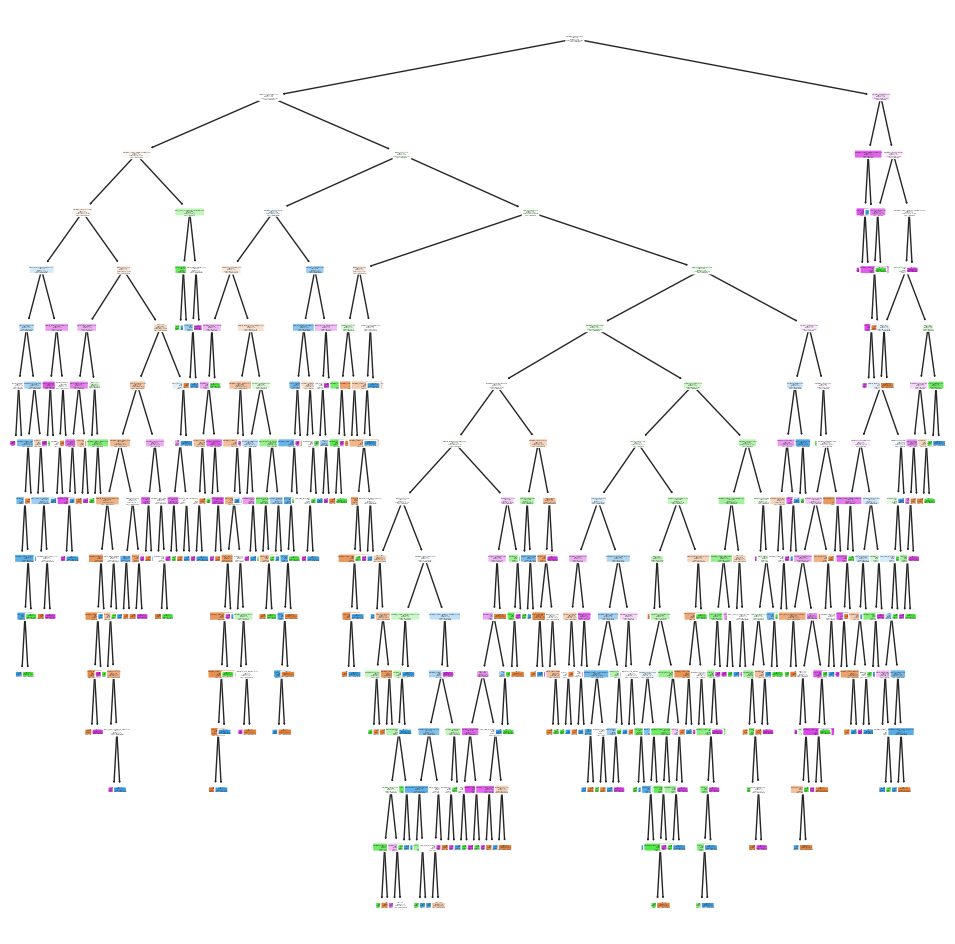

In [97]:
# Plot the trained Decision Tree
from sklearn.tree import plot_tree

f = plt.figure(figsize=(12,12))
plot_tree(dectree, filled=True, rounded=True, 
          feature_names=X_train.columns.tolist(), 
          class_names=["Wants-based","Impulsive", "Need-based", "Planned"])

# # Let's try using the XGBoost model to predict Purchase Intent

Label mapping:
0 -> Impulsive
1 -> Need-based
2 -> Planned
3 -> Wants-based
XGBoost Accuracy: 0.2640


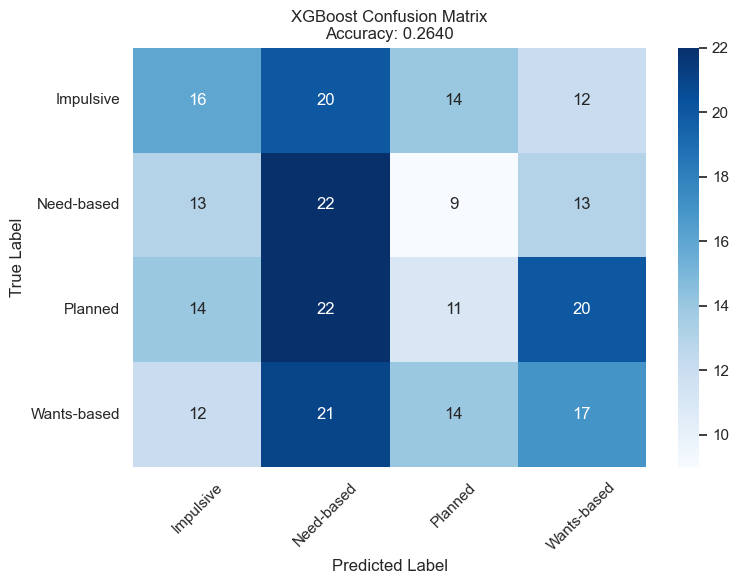


XGBoost Classification Report:
              precision    recall  f1-score   support

   Impulsive       0.29      0.26      0.27        62
  Need-based       0.26      0.39      0.31        57
     Planned       0.23      0.16      0.19        67
 Wants-based       0.27      0.27      0.27        64

    accuracy                           0.26       250
   macro avg       0.26      0.27      0.26       250
weighted avg       0.26      0.26      0.26       250



In [98]:
# Create label encoder
label_encoder = LabelEncoder()

# Convert string labels to numerical labels using ravel() to flatten
y_encoded = label_encoder.fit_transform(y.values.ravel())
y_train_encoded = label_encoder.transform(y_train.values.ravel())
y_test_encoded = label_encoder.transform(y_test.values.ravel())

print("Label mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i} -> {class_name}")

# Now fit XGBoost with encoded labels
xgb = make_pipeline(
    StandardScaler(),
    XGBClassifier(
    n_estimators=300, 
    learning_rate=0.05, 
    max_depth=15, 
    random_state=42
)
)

xgb.fit(X_train, y_train_encoded)

# Make predictions
y_pred_encoded = xgb.predict(X_test)

# Convert predictions back to original labels for interpretation
y_pred_xgb = label_encoder.inverse_transform(y_pred_encoded)

# Calculate accuracy
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")

# Plot confusion matrix with original labels
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title(f'XGBoost Confusion Matrix\nAccuracy: {xgb_accuracy:.4f}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Finally, let's try using Logistic Regression

In [99]:
# Initialize and fit model
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)
model.fit(X_train, y_train_encoded)

# Predict and evaluate
y_pred = model.predict(X_test)
print(confusion_matrix(y_test_encoded, y_pred))
print(classification_report(y_test_encoded, y_pred))


[[19 13 13 17]
 [21 17  8 11]
 [15 14 24 14]
 [18 13 13 20]]
              precision    recall  f1-score   support

           0       0.26      0.31      0.28        62
           1       0.30      0.30      0.30        57
           2       0.41      0.36      0.38        67
           3       0.32      0.31      0.32        64

    accuracy                           0.32       250
   macro avg       0.32      0.32      0.32       250
weighted avg       0.33      0.32      0.32       250



# Finally, comparing the models

In [100]:
# Calculate accuracies for all three models
acc_dectree = dectree.score(X_test, y_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
acc_logreg = accuracy_score(y_test_encoded, y_pred)

# Display comparison in a clean table
accuracy_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "XGBoost", "Logistic Regression"],
    "Accuracy": [acc_dectree, acc_xgb, acc_logreg]
})

print("\nModel Accuracy Comparison:")
print(accuracy_comparison.to_string(index=False))



Model Accuracy Comparison:
              Model  Accuracy
      Decision Tree     0.256
            XGBoost     0.264
Logistic Regression     0.320
